# 01 - Exploratory Data Analysis

## 1. Load data & build datetime index

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

DATA_PATH = "Bangladesh_Multi_Site_Air_Quality.csv"

df = pd.read_csv("../Bangladesh_Multi_Site_Air_Quality.csv")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Stations:", df["station"].unique())
print("Date range:", df["datetime"].min(), "->", df["datetime"].max())
df.head()

Shape: (208368, 19)
Stations: <ArrowStringArray>
['Barisal', 'Chittagong', 'Dhaka', 'Khulna', 'Rajshahi', 'Sylhet']
Length: 6, dtype: str
Date range: 2022-08-04 00:00:00 -> 2026-07-20 23:00:00


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,173641,2022,8,4,0,7.4,11.6,0.4,2.0,110.0,28.0,26.3,1003.8,25.0,0.0,SE,3.68,Barisal,2022-08-04 00:00:00
1,173642,2022,8,4,1,5.0,8.1,0.4,2.0,108.0,28.0,26.8,1004.8,24.8,0.1,SE,3.70,Barisal,2022-08-04 01:00:00
2,173643,2022,8,4,2,4.7,7.5,0.4,2.1,105.0,28.0,28.2,1004.5,25.0,0.0,SE,4.56,Barisal,2022-08-04 02:00:00
3,173644,2022,8,4,3,4.9,7.7,0.4,2.1,101.0,29.0,28.9,1004.8,25.1,0.0,SE,4.20,Barisal,2022-08-04 03:00:00
4,173645,2022,8,4,4,5.2,8.1,0.4,1.7,99.0,32.0,30.1,1004.6,25.4,0.2,SE,4.18,Barisal,2022-08-04 04:00:00


## 2. Missing values & basic stats

In [4]:
print("Missing values:\n", df.isna().sum())
print("\nPM2.5 describe:\n", df["PM2.5"].describe())

Missing values:
 No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

PM2.5 describe:
 count    208368.000000
mean         43.234646
std          32.274409
min           0.400000
25%          17.800000
50%          35.700000
75%          60.100000
max         312.000000
Name: PM2.5, dtype: float64


## 3. Spike rate\nA "spike" = PM2.5 > 150 µg/m³. This is the event we're trying to predict 1-3 hours ahead.

In [5]:
SPIKE_THRESHOLD = 150
df["is_spike"] = (df["PM2.5"] > SPIKE_THRESHOLD).astype(int)
spike_rate = df["is_spike"].mean() * 100
print(f"Overall spike rate (PM2.5 > {SPIKE_THRESHOLD}): {spike_rate:.3f}%")

spike_by_station = df.groupby("station")["is_spike"].mean() * 100
spike_by_station.sort_values(ascending=False)

Overall spike rate (PM2.5 > 150): 0.875%


station
Rajshahi      2.107809
Dhaka         1.197881
Khulna        1.134531
Barisal       0.650772
Sylhet        0.123819
Chittagong    0.037434
Name: is_spike, dtype: float64

## 4. Univariate distributions

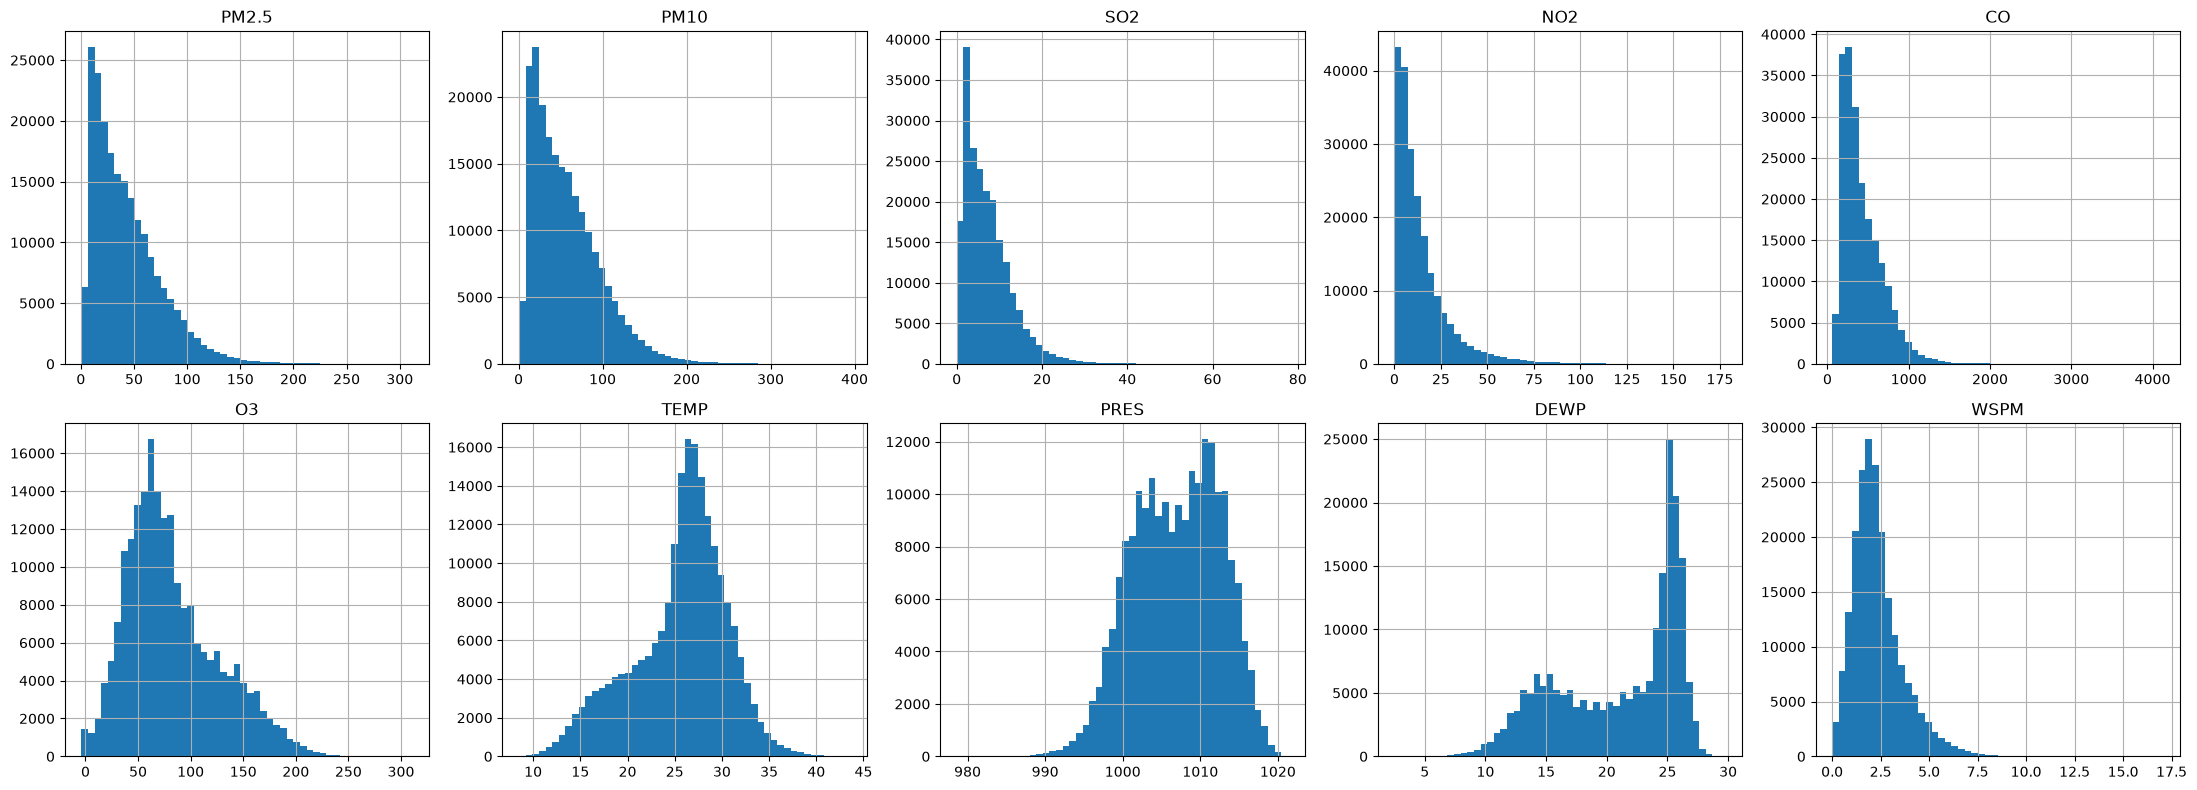

In [6]:
num_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "WSPM"]
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. PM2.5 by city\nConfirms which cities are worst (should show Dhaka high, matching the proposal's motivation slide).

<Figure size 1000x500 with 0 Axes>

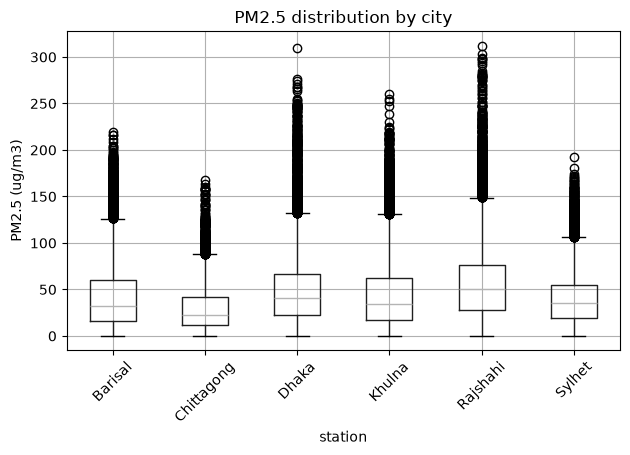

In [7]:
plt.figure(figsize=(10, 5))
df.boxplot(column="PM2.5", by="station", rot=45)
plt.title("PM2.5 distribution by city")
plt.suptitle("")
plt.ylabel("PM2.5 (ug/m3)")
plt.tight_layout()
plt.show()

## 6. PM2.5 by hour of day

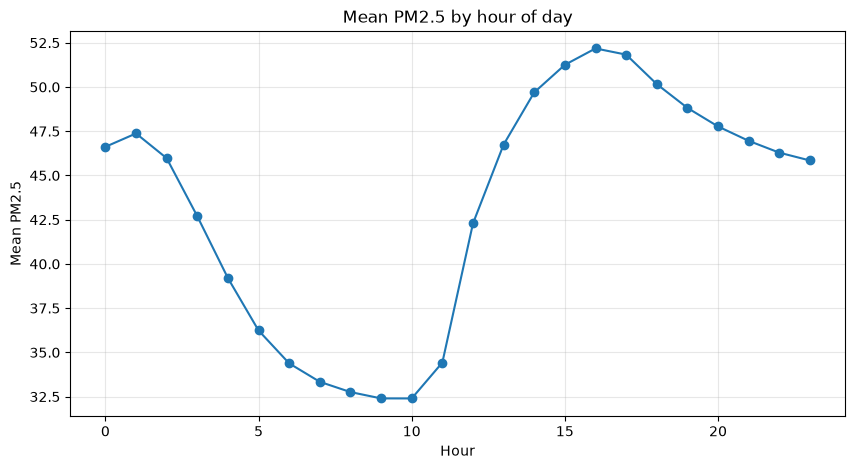

In [8]:
plt.figure(figsize=(10, 5))
df.groupby("hour")["PM2.5"].mean().plot(marker="o")
plt.title("Mean PM2.5 by hour of day")
plt.xlabel("Hour")
plt.ylabel("Mean PM2.5")
plt.grid(alpha=0.3)
plt.show()

## 7. PM2.5 by month (seasonality)\nShould show winter (brick-kiln season) spikes, supporting the proposal's motivation.

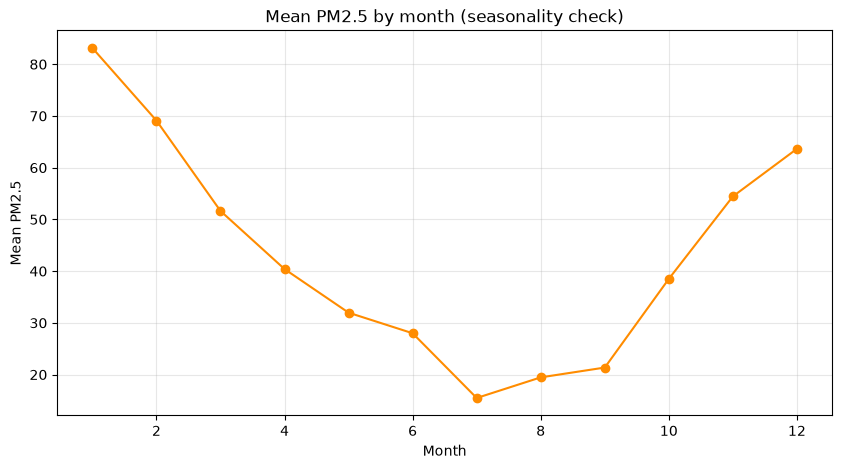

In [9]:
plt.figure(figsize=(10, 5))
df.groupby("month")["PM2.5"].mean().plot(marker="o", color="darkorange")
plt.title("Mean PM2.5 by month (seasonality check)")
plt.xlabel("Month")
plt.ylabel("Mean PM2.5")
plt.grid(alpha=0.3)
plt.show()

## 8. Correlation heatmap

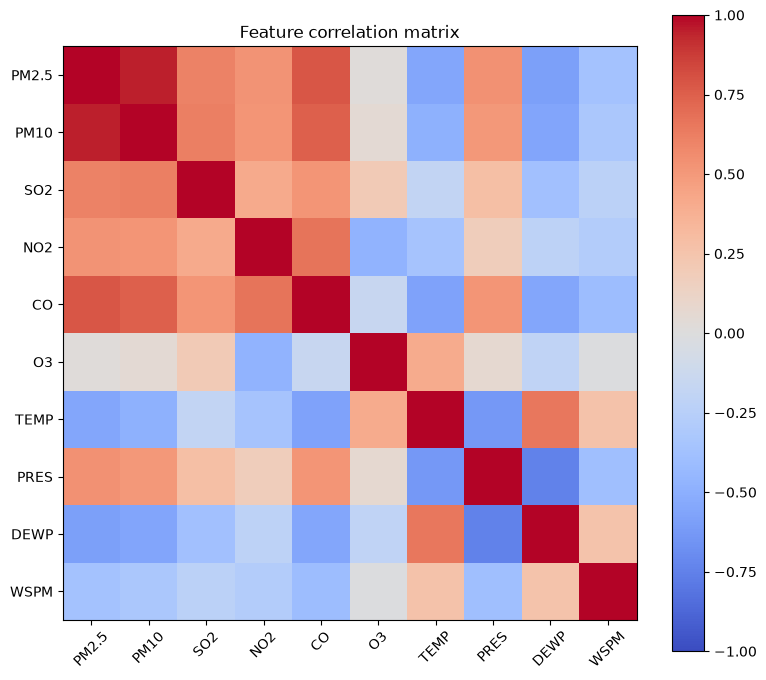

Correlation with PM2.5:


PM2.5    1.000000
PM10     0.950874
CO       0.784915
SO2      0.602006
PRES     0.531463
NO2      0.523632
O3       0.017248
WSPM    -0.359906
TEMP    -0.549926
DEWP    -0.592282
Name: PM2.5, dtype: float64

In [10]:
corr = df[num_cols].corr()
plt.figure(figsize=(8, 7))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(im)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print("Correlation with PM2.5:")
corr["PM2.5"].sort_values(ascending=False)

## 9. Wind direction frequency (wind rose proxy)

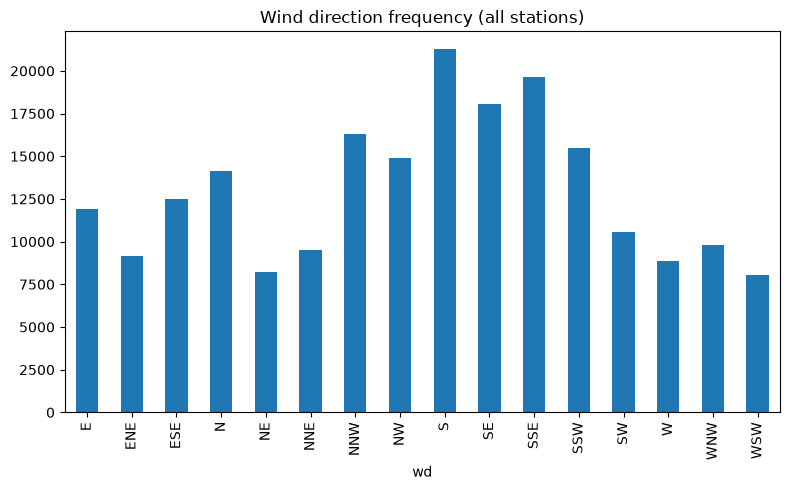

In [11]:
plt.figure(figsize=(8, 5))
df["wd"].value_counts().sort_index().plot(kind="bar")
plt.title("Wind direction frequency (all stations)")
plt.tight_layout()
plt.show()

## 10. Spike events over time

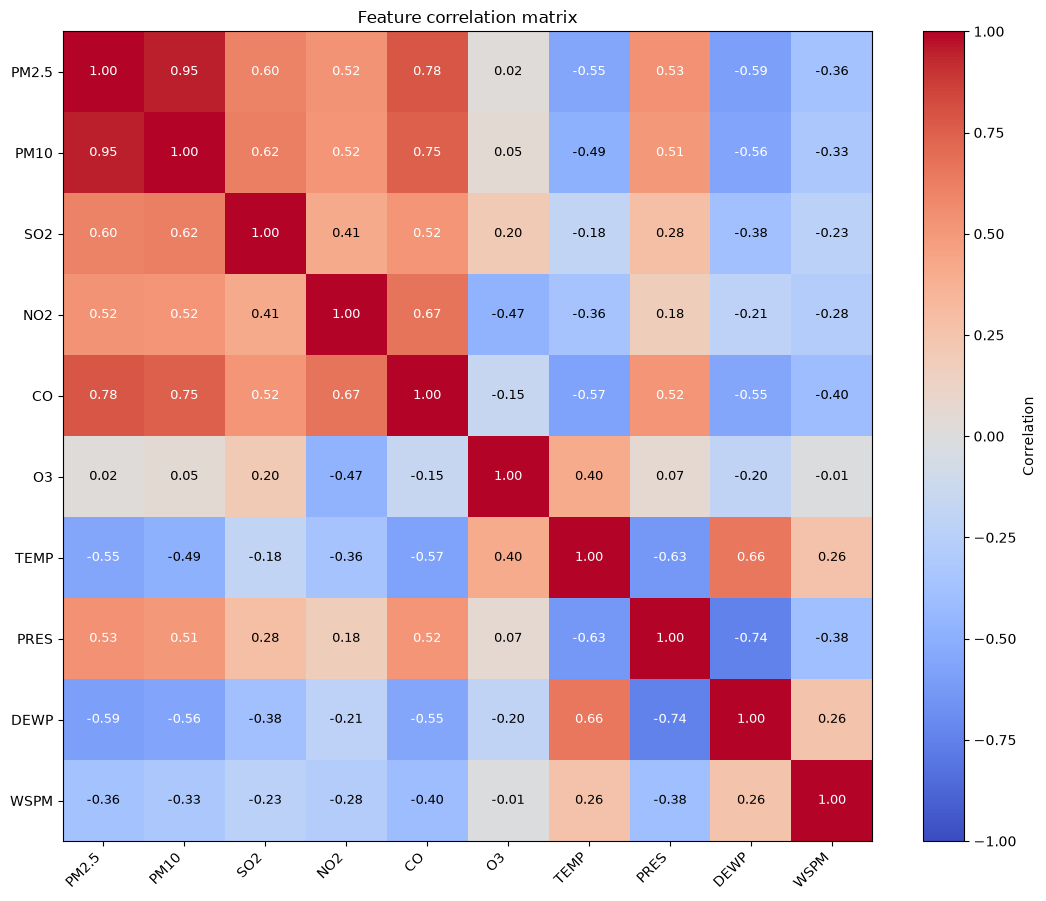

Correlation with PM2.5:


PM2.5    1.000000
PM10     0.950874
CO       0.784915
SO2      0.602006
PRES     0.531463
NO2      0.523632
O3       0.017248
WSPM    -0.359906
TEMP    -0.549926
DEWP    -0.592282
Name: PM2.5, dtype: float64

In [14]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)), num_cols)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Feature correlation matrix")

for row in range(len(num_cols)):
    for col in range(len(num_cols)):
        value = corr.iloc[row, col]
        text_color = "white" if abs(value) >= 0.5 else "black"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=9)

fig.tight_layout()
plt.show()

print("Correlation with PM2.5:")
corr["PM2.5"].sort_values(ascending=False)

## 11. Autocorrelation of PM2.5 (Dhaka example)
This tells us how far back in time PM2.5 values still carry predictive
signal about the current value - it directly justifies the lag features
(`pm25_lag_1`, `pm25_lag_6`, `pm25_lag_24`, etc.) used in feature engineering.
If the line stays outside the confidence band out to, say, 15 hours, those
lags are worth including as model features.

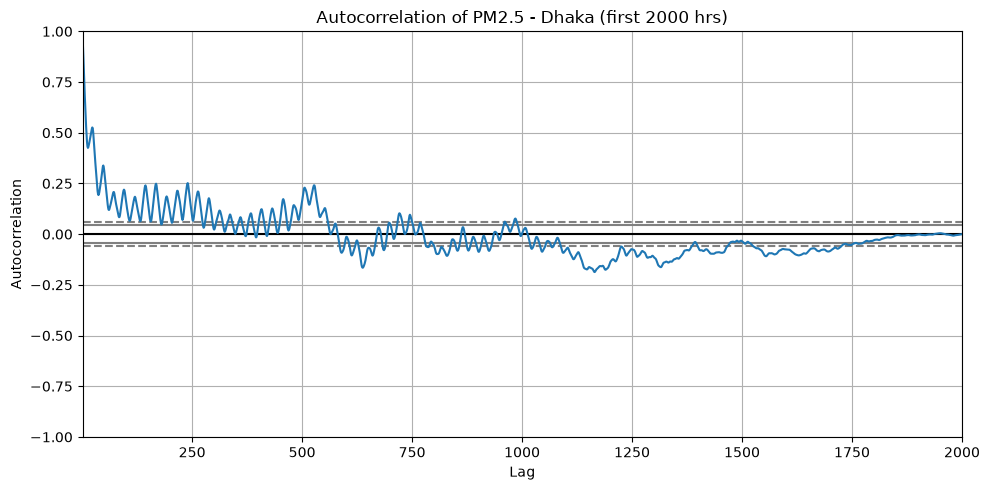

Autocorrelation at lag 1h: 0.982
Autocorrelation at lag 3h: 0.895
Autocorrelation at lag 6h: 0.751
Autocorrelation at lag 12h: 0.631
Autocorrelation at lag 24h: 0.807


In [13]:
from pandas.plotting import autocorrelation_plot

dhaka = df[df["station"] == "Dhaka"].set_index("datetime")["PM2.5"]
plt.figure(figsize=(10, 5))
autocorrelation_plot(dhaka.iloc[:2000])  # subset for speed/readability
plt.title("Autocorrelation of PM2.5 - Dhaka (first 2000 hrs)")
plt.tight_layout()
plt.show()

# numeric values at a few key lags, useful to cite directly in a report
for lag in [1, 3, 6, 12, 24]:
    ac = dhaka.autocorr(lag=lag)
    print(f"Autocorrelation at lag {lag}h: {ac:.3f}")